# Lecture 19 - Multinomial Logistic Regression, Support Vector Machines (SVMs) & Lagrange Multipliers

## The Objective Function for a 2-class Problem with Logistic Regression

Let $\{(x_i,t_i)\}_{i=1}^N$ be the set of input samples and its class labels, where $t_i\in\{0,1\}$. Assuming the data samples are i.i.d., we can build the observed data likelihood:

\begin{align*}
\mathcal{L}^0 = \prod_{i=1}^N P(y_i|x_i; \mathbf{w}) = \phi(z_i)^{t_i}(1-\phi(z_i))^{1-t_i}
\end{align*}

We can apply the "trick" (log-likelihood) to build the data likelihood":

\begin{align*}
\mathcal{L} = \sum_{i=1}^N t_i\log\phi(z_i) +(1-t_i)\log(1-\phi(z_i))
\end{align*}

where $\phi(z) = \frac{1}{1+\exp(-z)}$ and $z_i = \mathbf{w}^Tx_i+w_0$.

We want to maximize this likelihood to the data, or we can also write it as a minimization optimization:

\begin{align*}
J(\mathbf{w},w_0) = \sum_{i=1}^N - t_i\log\phi(z_i) - (1-t_i)\log(1-\phi(z_i))
\end{align*}

This objective function is also known as **cross-entropy**.

We can see that the cost approaches 0 if we correctly predict that a sample belongs to class 1. Similarly, we can see on the y axis that the cost also approaches 0 if we correctly predict class 0. However, if the prediction is wrong, the cost goes towards infinity: we penalize wrong predictions with an increasingly larger cost.

As we do not have the global *picture* of what the objective function, $J(\mathbf{w})$, we apply a search method to navigate through the objective function to find the *local optima* starting from an initial value, namely, **gradient descent**.

\begin{align*}
\mathbf{w}^{(t+1)} \longleftarrow \mathbf{w}^{(t)} - \eta \frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}}
\end{align*}

\begin{align*}
\mathbf{w_0}^{(t+1)} \longleftarrow \mathbf{w_0}^{(t)} - \eta \frac{\partial J(\mathbf{w})}{\partial \mathbf{w_0}^{(t)}}
\end{align*}

where $\eta$ is the learning rate (or step size).

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}} =
-\sum_{i=1}^N \left[t_i\frac{1}{\phi(z_i)}\frac{\partial\phi(z_i)}{\partial z_i}\frac{\partial z_i}{\partial\mathbf{w}} -(1-t_i)\frac{1}{1-\phi(z_i)}\frac{\partial\phi(z_i)}{\partial z_i}\frac{\partial z_i}{\partial\mathbf{w}} \right]
\end{align*}

where $\frac{\partial\phi(z_i)}{\partial z_i} = \phi'(z_i)$ and $\frac{\partial z_i}{\partial\mathbf{w}} = x_i$. Substituting:

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}} &= \sum_{i=1}^N -t_i \frac{\phi'(z_i)}{\phi(z_i)} x_i + (1-t_i)\frac{\phi'(z_i)}{1-\phi(z_i)} x_i \\
&= \sum_{i=1}^N \left(-\frac{t_i}{\phi(z_i)} + \frac{1-t_i}{1-\phi(z_i)}\right)\phi'(z_i)x_i
\end{align*}

where $\phi'(z_i)= \phi(z_i)(1-\phi(z_i))$, then applying some substitutions we have:

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}} = - \sum_{i=1}^N (t_i - y_i)x_i
\end{align*}

and, similarly,

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial w_0^{(t)}} = - \sum_{i=1}^N (t_i - y_i)
\end{align*}

Finally,

\begin{align*}
\mathbf{w}^{(t+1)} \longleftarrow \mathbf{w}^{(t)} + \eta \sum_{i=1}^N (t_i - y_i)x_i
\end{align*}

\begin{align*}
\mathbf{w_0}^{(t+1)} \longleftarrow \mathbf{w_0}^{(t)} + \eta \sum_{i=1}^N (t_i - y_i)
\end{align*}

**Initialization:** it is best to initialize $\mathbf{w}$ with random values close to 0; generally they are drawn uniformly from the interval $[−0.01, 0.01]$. 

* The reason for this is that if the initial $\mathbf{w}$ are large in magnitude, the weighted sum may also be large and may saturate the sigmoid. 

* If the initial weights are close to 0, the sum will stay in the middle region where the derivative is nonzero and an update can take place. 

* If the weighted sum is large in magnitude (smaller than −5 or larger than +5), the derivative of the sigmoid will be almost 0 and weights will not be updated. 
    * When we stack up a lot of these perceptrons in layers and add a few layers, this "close to 0" gradient will lead to a phenomenon in neural networks known as the **vanishing gradient**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')

((450, 2), (450,))

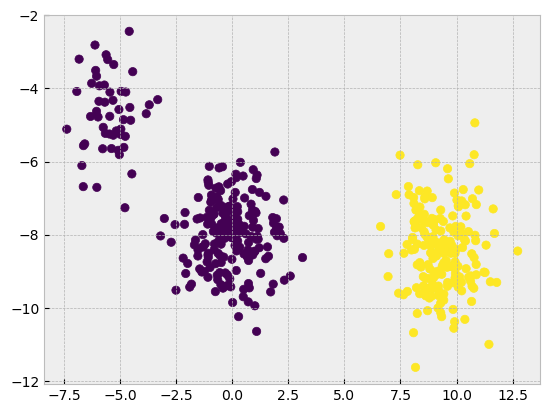

In [2]:
X = np.load('data.npy')
t = np.load('labels.npy')

plt.scatter(X[:,0], X[:,1], c=t);

X.shape, t.shape

In [3]:
# Scale the data with Standardization
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.linear_model import LogisticRegression

In [5]:
log_reg = LogisticRegression(penalty=None)
# penalty is the "regularizer term"

In [6]:
log_reg.fit(X_scaled, t)

LogisticRegression(penalty=None)

In [7]:
w0_lr = log_reg.intercept_

w0_lr

array([-3.17079891])

In [8]:
w_lr = log_reg.coef_

w_lr

array([[14.19479195,  0.37301732]])

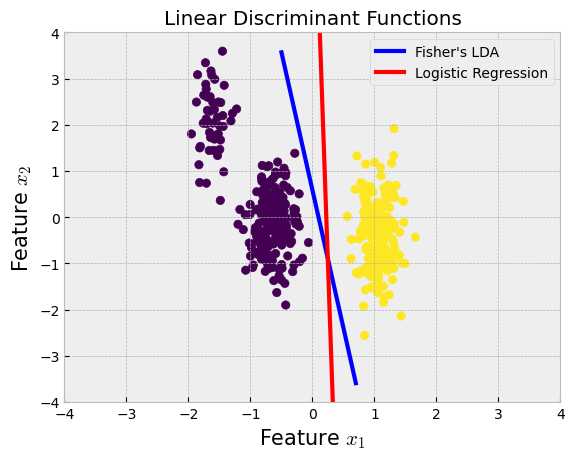

In [9]:
# DISCRIMINANT FUNCTIONS

# Logistic Regression 
y_lr = -w0_lr[0]/w_lr[:,1] - (w_lr[:,0]/w_lr[:,1])*np.linspace(0,0.4,X.shape[0])

# LDA
m1 = np.mean(X_scaled[t==0,:],axis=0).reshape(-1,1)
m2 = np.mean(X_scaled[t==1,:],axis=0).reshape(-1,1)
SB = (m2-m1)@(m2-m1).T
SW = (X_scaled[t==0,:]-m1.T).T@(X_scaled[t==0,:]-m1.T) + (X_scaled[t==1,:]-m2.T).T@(X_scaled[t==1,:]-m2.T)
L, E = np.linalg.eigh(np.linalg.inv(SW)@SB)
w_lda = E[:,-1]
w0_lda = (m1+m2).T@w_lda/2
y_lda = w0_lda/w_lda[1] - (w_lda[0]/w_lda[1])*np.linspace(-0.5,0.7,X.shape[0])

plt.scatter(X_scaled[:,0],X_scaled[:,1],c=t)
plt.plot(np.linspace(-0.5,0.7,X.shape[0]), y_lda,'blue',linewidth=3, label="Fisher's LDA")
plt.plot(np.linspace(0,0.4,X.shape[0]), y_lr,'red',linewidth=3, label='Logistic Regression')
plt.title('Linear Discriminant Functions');plt.axis([-4,4,-4,4]);
plt.legend(loc='best',fontsize=10)
plt.xlabel('Feature $x_1$', size=15); plt.ylabel('Feature $x_2$',size=15);

In [10]:
# generate synthetic data in the 2-D feature space

xx, yy = np.meshgrid(np.arange(-4, 4, 0.01),
                     np.arange(-4, 4, 0.01))

mesh = np.vstack((xx.ravel(), yy.ravel())).T

xx.shape, yy.shape, mesh.shape

((800, 800), (800, 800), (640000, 2))

In [11]:
sigmoid = lambda x: 1/(1+np.exp(-x))

In [12]:
# Making predictions

#y = sigmoid(w^T@x + b) = sigmoid(x@w^T + b)

sigmoid(mesh@log_reg.coef_.T + log_reg.intercept_)

array([[2.07044083e-27],
       [2.38621747e-27],
       [2.75015531e-27],
       ...,
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00]])

In [13]:
probs = log_reg.predict_proba(mesh)

probs

array([[1.00000000e+00, 2.07044083e-27],
       [1.00000000e+00, 2.38621747e-27],
       [1.00000000e+00, 2.75015531e-27],
       ...,
       [0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00]])

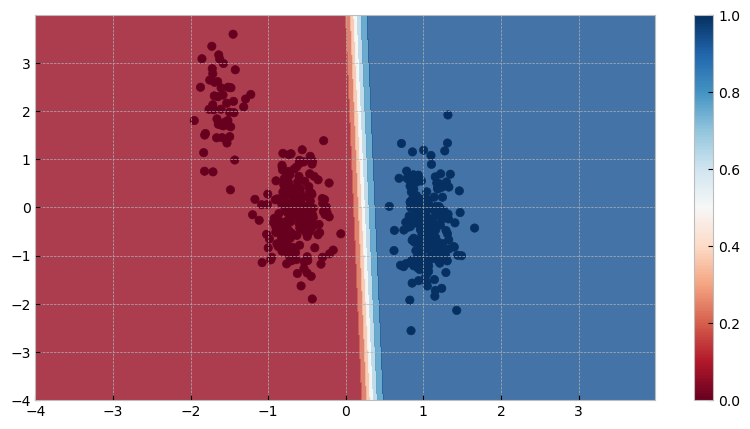

In [14]:
plt.figure(figsize=(10,5))
plt.contourf(xx, yy, probs[:,1].reshape(xx.shape), cmap=plt.cm.RdBu, alpha=.8)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=t, cmap=plt.cm.RdBu)
plt.colorbar();

In [15]:
labels = log_reg.predict(mesh)

labels

array([0., 0., 0., ..., 1., 1., 1.])

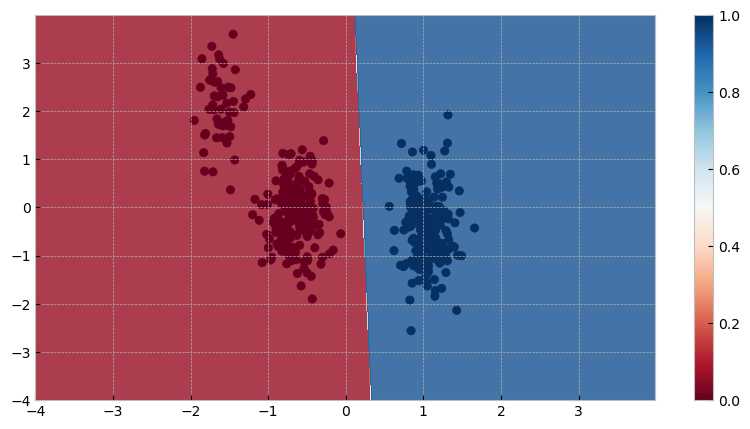

In [16]:
plt.figure(figsize=(10,5))
plt.contourf(xx, yy, labels.reshape(xx.shape), cmap=plt.cm.RdBu, alpha=.8)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=t, cmap=plt.cm.RdBu)
plt.colorbar();

## Multiple Classes

Considering the extension of linear discriminants to $K > 2$ classes. We might be tempted be to build a $K$-class discriminant by combining a number of two-class discriminant functions. However, this leads to some serious difficulties.

* Consider the use of $K−1$ classifiers each of which solves a two-class problem of separating points in a particular class $C_k$ from points not in that class. This is known as a **one-versus-all** classifier.

* An alternative is to introduce $K(K − 1)/2$ binary discriminant functions, one for every possible pair of classes. This is known as a **one-versus-one** classifier. Each point is then classified according to a majority vote amongst the discriminant functions. However, this too runs into the problem of ambiguous regions.

## Softmax Regression

We can avoid these difficulties by considering a **single $K$-class discriminant** comprising $K$ linear functions of the form

\begin{align*}
y_k(\mathbf{x}) = \phi(\mathbf{w}_k^T\mathbf{x} + b_k) = \phi(v_k)
\end{align*}

and then assigning a point $\mathbf{x}$ to class $C_k$ if $y_k(\mathbf{x}) > y_j(\mathbf{x})$ for all $j \neq k$. The decision
boundary between class $C_k$ and class $C_j$ is therefore given by $y_k(\mathbf{x}) = y_j(\mathbf{x})$ and hence corresponds to a $(D − 1)$-dimensional hyperplane defined by

\begin{align*}
(\mathbf{w}_k - \mathbf{w}_j)^T\mathbf{x} + (b_k - bj) = 0
\end{align*}

This has the same form as the decision boundary for the two-class case.

The decision regions of such a discriminant are always **singly connected** and **convex**.

Once you have computed the score of every class for the instance $\mathbf{x}$, i.e. $v_k(\mathbf{x})$, you can estimate the probability $p_k$ that the instance belongs to class $k$ by running the scores through the **softmax function**.

\begin{align*}
p_k = \frac{\exp(v_k(\mathbf{x}))}{\sum_{j=1}^K \exp(v_j(\mathbf{x}))}
\end{align*}

The function computes the exponential of every score, then normalizes them (dividing by the sum of all the exponentials). The scores are generally called logits or log-odds (although they are actually unnormalized log-odds).

The derivations will be derived in the same way as earlier (left as exercise).

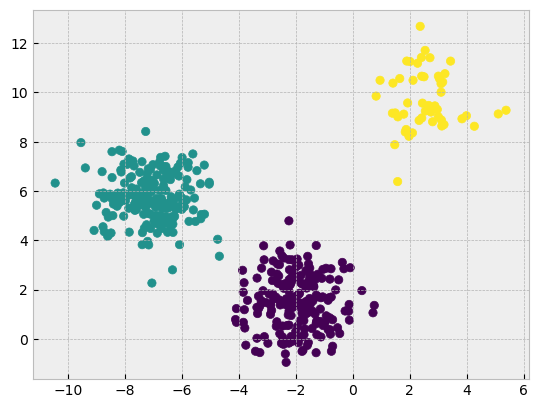

In [24]:
X = np.load('data_2.npy')
t = np.load('labels_2.npy')

plt.scatter(X[:,0], X[:,1], c=t);

In [25]:
# Scaling Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
log_reg = LogisticRegression(penalty=None)

In [27]:
log_reg.fit(X_scaled, t)

LogisticRegression(penalty=None)

In [28]:
probs = log_reg.predict_proba(mesh)

probs

array([[7.74467355e-21, 1.00000000e+00, 1.05048926e-53],
       [9.72272005e-21, 1.00000000e+00, 1.33126501e-53],
       [1.22059741e-20, 1.00000000e+00, 1.68708677e-53],
       ...,
       [4.57451776e-27, 7.38983243e-46, 1.00000000e+00],
       [4.53165753e-27, 5.83125037e-46, 1.00000000e+00],
       [4.48919886e-27, 4.60138727e-46, 1.00000000e+00]])

In [29]:
pred = log_reg.predict(mesh)

pred

array([1., 1., 1., ..., 2., 2., 2.])

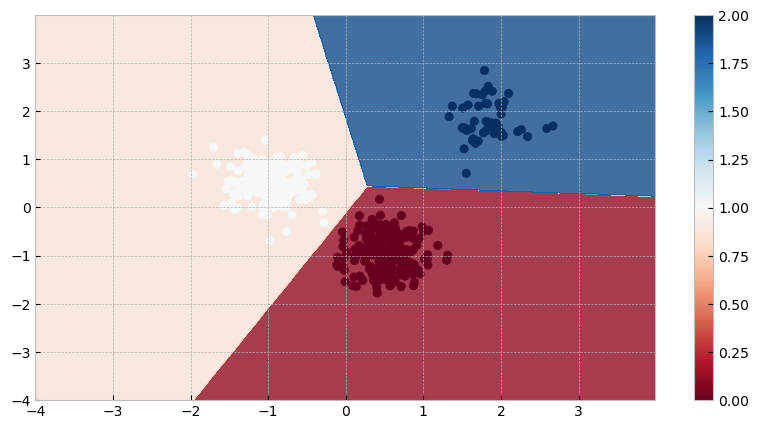

In [30]:
xx, yy = np.meshgrid(np.arange(-4, 4, 0.01),
                     np.arange(-4, 4, 0.01))
mesh = np.vstack((xx.ravel(), yy.ravel())).T

probs = log_reg.predict(mesh)

plt.figure(figsize=(10,5))
plt.contourf(xx, yy, probs.reshape(xx.shape), cmap=plt.cm.RdBu, alpha=.8)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=t, cmap=plt.cm.RdBu)
plt.colorbar();

---

# Hard-Margin Support Vector Machine (SVM): Linearly Separable Classes

Let's start with the two-class linearly separable task and then we will extend the method to more general cases where data are not separable. Let $\phi(x_i)$, $i=1,2,\dots,N$, be the feature vectors of the training set, $X$, and corresponding target values $t_1, t_2, \cdots, t_N$ where $t_n\in\{-1,1\}$. These belong to either of two classes, $C_1$, $C_2$, which are *assumed to be linearly separable*.

The goal, once more, is to design a hyperplane

$$y(x) = w^T\phi(x) + b$$

that classifies correctly all the training vectors.

Because the training data is linearly separable in the feature space, by definition there exists at least one choice of the parameters $w$ and $b$ such that $y(x)$ satisfies $y(x_n)>0$ for points having $t_n = +1$ and $y(x_n)<0$ for points having $t_n = -1$, so that $t_ny(x_n) > 0$ for all training data points.

Such a hyperplane is not unique. The perceptron algorithm may converge to any one of the possible solutions. Having gained in experience, this time we will be more demanding. 

* Which hyperplane would any sensible engineer choose as the classifier for operation in practice, where data outside the training set will be fed to it? 

* Once again, the hyperplane that leaves more “room” on either side, so that data in both classes can move a bit more freely, with less risk of causing an error. 

* A sensible choice for the hyperplane classifier would be the one that leaves the maximum margin from both classes.

* Thus such a hyperplane can be trusted more, when it is faced with the challenge of operating with unknown data.
    * It has a higher generalizarion performance.

## Quantifying the "Margin"

Let us now quantify the term "margin" that a hyperplane leaves from both classes. Every hyperplane is characterized by its direction (determined by $w$) and its exact position in space (determined by $b$). Since we want to give no preference to either of the classes, then it is reasonable for each direction to select that hyperplane which has the same distance from the respective nearest points in $c_1$ and $c_2$.

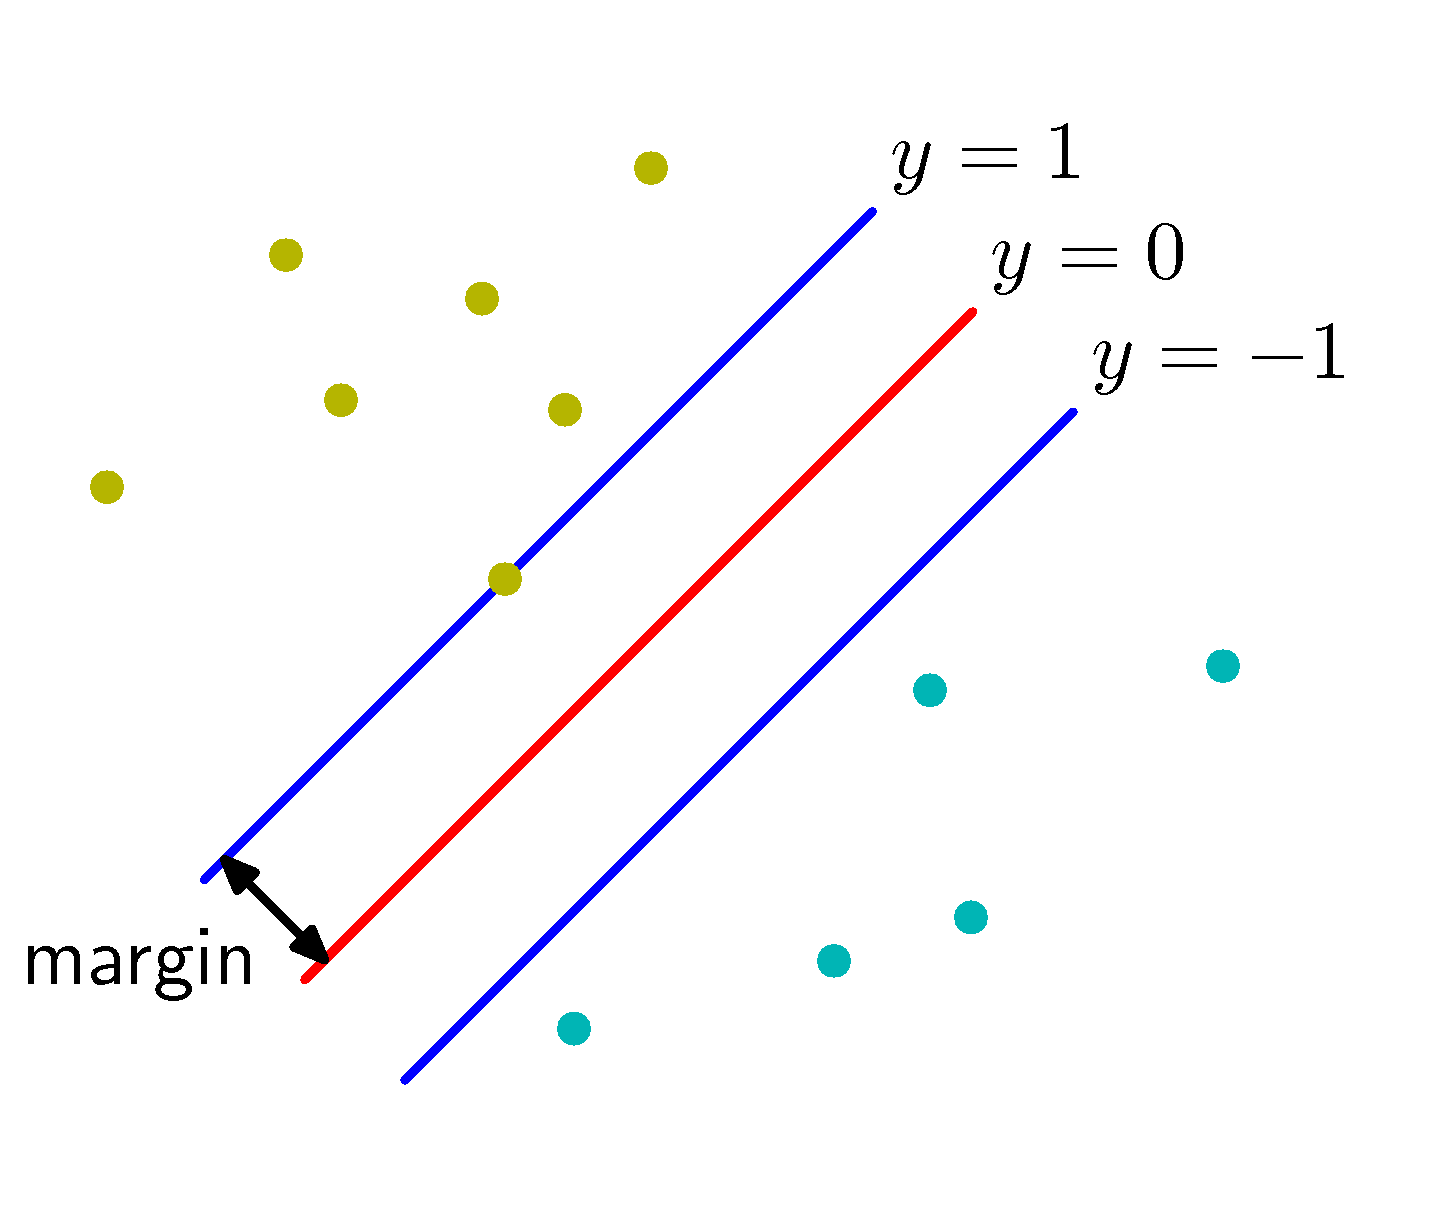

In [1]:
from IPython.display import Image
Image('figures/Figure7.1a.png', width=400)
#Source: Bishop textbook

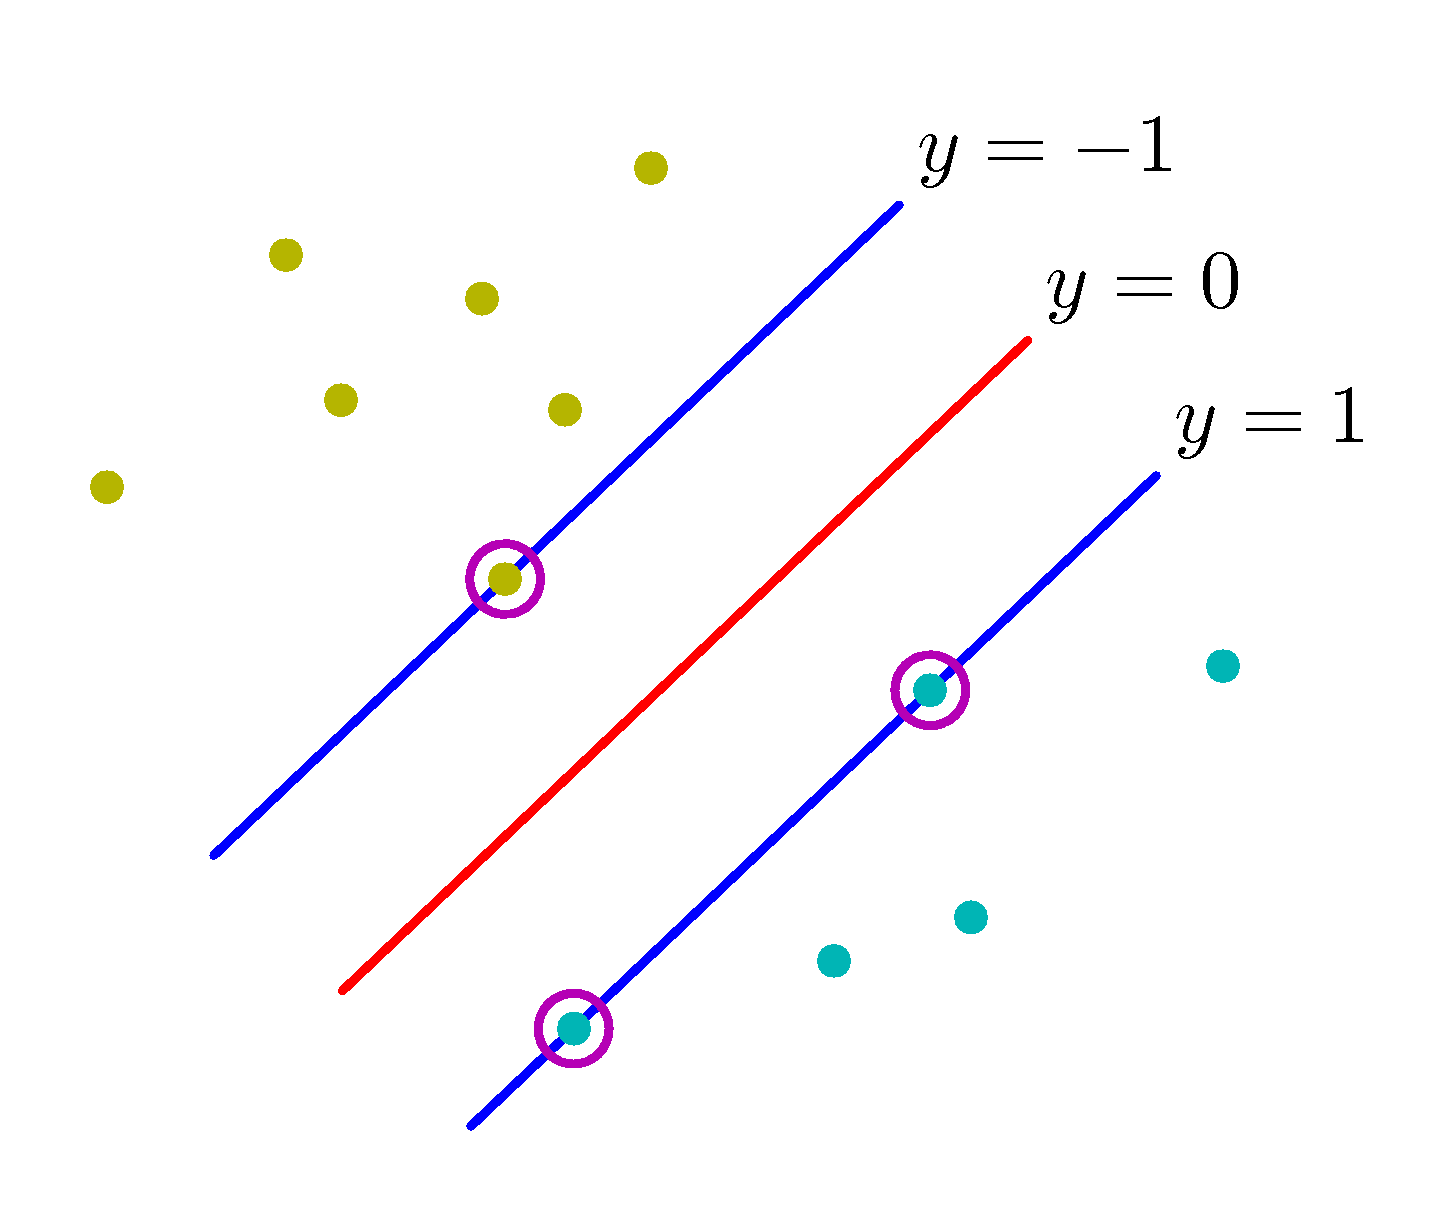

In [2]:
Image('figures/Figure7.1b.png', width=400)
#Source: Bishop textbook

Recall that the perpendicular distance of a point $x$ from a hyperplane defined by $y(x) = 0$ where $y(x)$ takes the form $y(x) = w^T\phi(x)+b$ is given by $\frac{|y(x)|}{\Vert w\Vert}$.


Furthermore, we are only interested in solutions for which all data points are correctly classified, so that $t_n y(x_n) > 0, \forall n$. Thus the distance of a point $x_n$ to the decision surface is given by

$$\frac{t_n y(x_n)}{\Vert w\Vert} = \frac{t_n \left(w^t\phi(x_n) + b\right)}{\Vert w\Vert}$$

The margin is given by the perpendicular distance to the closest point $x_n$ from the data set, and we wish to optimize the parameters $w$ and $b$ in order to maximize this distance. Thus the maximum margin solution is found by solving

$$\arg_{w,b}\max \left\{\frac{1}{\Vert w\Vert}\min_n \left[t_n(w^T\phi(x_n)+b)\right]\right\}$$

where the factor $\frac{1}{\Vert w\Vert}$ is taken outside the optimization over $n$ because $w$ does not depend on $n$.

* Direct solution of this optimization problem would be very complex, and so we shall convert it into an equivalent problem that is much easier to solve. 

* To do this we note that if we make the rescaling $w\rightarrow \kappa w$ and $b\rightarrow \kappa b$, then the distance from any point $x_n$ to the decision surface, given by $\frac{t_n y(x_n)}{\Vert w\Vert}$, is unchanged. We can use this freedom to set

$$t_n(w^T\phi(x_n)+b) = 1$$

for the point that is closest to the surface, called the **support vectors**. In this case, all data points will satisfy the constraints

$$t_n(w^T\phi(x_n)+b) \geq 1, n=1, 2, \dots, N$$

* This is known as the canonical representation of the decision hyperplane. 

* In the case of data points for which the equality holds (support vectors), the constraints are said to be active, whereas for the remainder they are said to be inactive. 

* By definition, there will always be at least one active constraint, because there will always be a closest point, and once the margin has been maximized there will be at least two active constraints.

The optimization problem then simply requires that we maximize $\Vert w\Vert^{-1}$, which is equivalent to minimizing $\Vert w\Vert^2$, and so we have to solve the optimization problem

\begin{align*}
&\arg_{w,b}\min \frac{1}{2} \Vert w\Vert^2 \\
& \text{subject to } t_n(w^T\phi(x_n)+b) \geq 1
\end{align*}

---

# Constrained Optimization with Lagrange Multipliers

*See board notes*.

Reading suggestion:
* ["Appendix E. Lagrange Multipliers"](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf), Bishop textbook, pp. 707-710.

---